<a href="https://colab.research.google.com/github/xukanz/RLVR/blob/main/Baseline1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baselines 1 & 2: frozen SAM ViT-B encoder + conv seg head on MoNuSeg

- **Baseline 1**: supervised BCE + Dice on **weak labels** (radius-4 px point discs + Voronoi boundaries). Lower bound.
- **Baseline 2**: supervised BCE + Dice on **full masks** (instance masks merged to foreground). Upper bound.

Raw data, processed labels, the embedding cache and checkpoints all live on Drive under `MyDrive/s_seg_rlvr`.

## After a Colab runtime reconnect

**Runtime → Run all** is safe. One-time cells start with `%%skip_if <condition>` and print `[skipped: ...]` when their results already exist on Drive.

| Section | After reconnect | Skip condition |
|---|---|---|
| 0. Setup | ▶ run | |
| 1. Definitions | ▶ run | |
| 2. Data preprocessing | ⏭ auto-skip | `PREP_DONE`: `summary.json`, `split.json`, `tiles.json` exist |
| 3. SAM embedding cache | ⏭ auto-skip | `CACHE_DONE`: 2286 `.npy` files in the cache |
| 4. Post-processing reference (GT) | ▶ run (seconds) | |
| 5. Baseline 2 training | ⏭ auto-skip | `full_s0.pt` reached 5000 steps (a partial checkpoint resumes) |
| 5. Baseline 2 evaluation | ▶ run | |
| 6. Baseline 1 training | ⏭ auto-skip | `weak_s0.pt` reached 5000 steps (a partial checkpoint resumes) |
| 6. Baseline 1 evaluation / analysis | ▶ run | |

Evaluation needs a GPU runtime (seg-head inference on 54 val tiles, under a minute). The SAM encoder is only loaded when the cache has to be rebuilt.


## 0. Setup

In [ ]:
!nvidia-smi

Thu Oct  1 19:18:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python-headless pycocotools matplotlib scikit-image scipy tqdm

import os, json, glob, cv2, numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

ROOT = "/content/drive/MyDrive/s_seg_rlvr"
RAW = f"{ROOT}/data/monuseg/raw/train"
OUT = PROC = f"{ROOT}/data/monuseg/processed"
CACHE = f"{ROOT}/cache/emb_vitb"
for d in ["checkpoints", "data", "logs", "cache"]:
    os.makedirs(f"{ROOT}/{d}", exist_ok=True)

Mounted at /content/drive


  Preparing metadata (setup.py) ... done


In [ ]:
import segment_anything
print("segment_anything imported successfully")

segment_anything imported successfully


In [ ]:
print(os.listdir(f"{ROOT}/checkpoints"))
print(len(glob.glob(f"{CACHE}/*.npy")), "(expected 2286)")
print(os.listdir(PROC))
summary = json.load(open(f"{PROC}/summary.json"))
val = json.load(open(f"{PROC}/split.json"))["val"]

['sam_vit_b_01ec64.pth', 'full_s0.pt']
2286 (expected 2286)
['inst', 'points', 'weak', 'summary.json', 'split.json', 'tiles.json']


In [ ]:
# `%%skip_if <expr>` as the first line of a cell skips the cell when <expr> is true.
# One-time cells (preprocessing, embedding cache, training) use it so "Run all" is safe after a reconnect.
from IPython.core.magic import register_cell_magic

@register_cell_magic
def skip_if(line, cell):
    if eval(line, get_ipython().user_ns):
        print(f"[skipped: {line.strip()} is True]")
        return
    get_ipython().run_cell(cell).raise_error()

def trained(tag, steps=5000, seed=0):
    ck = f"{ROOT}/checkpoints/{tag}_s{seed}.pt"
    return os.path.exists(ck) and torch.load(ck, map_location="cpu")["step"] >= steps

PREP_DONE = all(os.path.exists(f"{PROC}/{f}") for f in ["summary.json", "split.json", "tiles.json"])
CACHE_DONE = len(glob.glob(f"{CACHE}/*.npy")) == 2286
print("PREP_DONE:", PREP_DONE, "| CACHE_DONE:", CACHE_DONE,
      "| full trained:", trained("full"), "| weak trained:", trained("weak"))

## 1. Definitions

Augmentation, dataset, seg head, loss, training loop, post-processing, metrics and analysis helpers. No outputs; nothing here touches Drive.

In [ ]:
def apply_aug(a, k):
    """k in 0..7: low 2 bits = rotate 90° k%4 times, 3rd bit = horizontal flip"""
    a = np.rot90(a, k % 4, axes=(0, 1))
    if k >= 4:
        a = a[:, ::-1]
    return np.ascontiguousarray(a)

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, cv2, json, os
from torch.utils.data import Dataset, DataLoader

PROC = OUT  # processed directory

class TileDS(Dataset):
    def __init__(self, part, mode="weak"):   # mode: "weak" or "full"
        self.items = json.load(open(f"{PROC}/tiles.json"))[part]
        self.part, self.mode = part, mode
        self.augs = list(range(8)) if part == "train" else [0]
        self.index = [(t, k) for t in self.items for k in self.augs]
        self.cache = {}

    def _load(self, stem):
        if stem not in self.cache:
            if len(self.cache) > 8: self.cache.clear()
            self.cache[stem] = (
                cv2.imread(f"{PROC}/weak/{stem}.png", 0),
                np.load(f"{PROC}/inst/{stem}.npy", mmap_mode="r"))
        return self.cache[stem]

    def __len__(self): return len(self.index)

    def __getitem__(self, i):
        t, k = self.index[i]
        stem, y, x = t["stem"], t["y"], t["x"]
        emb = np.load(f"{CACHE}/{stem}_{y}_{x}_a{k}.npy")
        weak, inst = self._load(stem)
        if self.mode == "weak":
            lab = apply_aug(weak[y:y+512, x:x+512], k)           # 0/1/255
        else:
            m = (np.asarray(inst[y:y+512, x:x+512]) > 0).astype(np.uint8)
            lab = apply_aug(m, k)                                 # 0/1, no ignore
        return torch.from_numpy(emb).float(), torch.from_numpy(lab.astype(np.int64))

class SegHead(nn.Module):
    def __init__(self, cin=256, c=128):
        super().__init__()
        def blk(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1),
                                 nn.GroupNorm(8, o), nn.GELU())
        self.b1, self.b2, self.b3 = blk(cin, c), blk(c, c // 2), blk(c // 2, c // 4)
        self.out = nn.Conv2d(c // 4, 1, 1)
    def forward(self, x):
        for b in (self.b1, self.b2, self.b3):
            x = b(F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False))
        return self.out(x).squeeze(1)    # (B, 512, 512)

In [ ]:
def masked_loss(logits, lab, pos_weight=None):
    valid = lab != 255
    if valid.sum() == 0:
        return logits.sum() * 0
    p, t = logits[valid], lab[valid].float()
    pw = None if pos_weight is None else torch.tensor(pos_weight, device=p.device)
    bce = F.binary_cross_entropy_with_logits(p, t, pos_weight=pw)
    s = torch.sigmoid(p)
    dice = 1 - (2 * (s * t).sum() + 1) / (s.sum() + t.sum() + 1)
    return bce + dice

Loss Function

Total loss

$$
\mathcal{L} = \mathcal{L}_{\mathrm{BCE}} + \mathcal{L}_{\mathrm{Dice}}
$$

Definitions

Let $\Omega$ be the set of pixels that contribute to the loss, $z_i$ the logit of pixel $i$, $p_i = \sigma(z_i)$ the predicted foreground probability, $t_i \in \{0,1\}$ the label, and $w$ the positive-class weight (`pos_weight`).

$$
\mathcal{L}_{\mathrm{BCE}} = -\frac{1}{|\Omega|} \sum_{i \in \Omega}
\Big[ w \, t_i \log p_i + (1 - t_i) \log (1 - p_i) \Big]
$$

$$
\mathcal{L}_{\mathrm{Dice}} = 1 - \frac{2 \sum_{i \in \Omega} p_i t_i + 1}
{\sum_{i \in \Omega} p_i + \sum_{i \in \Omega} t_i + 1}
$$

Full vs. weak supervision

$$
\text{Full supervision:}\quad \Omega = \{\text{all pixels}\},\quad
t_i = \mathbb{1}[\mathrm{inst}_i > 0],\quad w = 1
$$

$$
\text{Weak supervision:}\quad \Omega = \{\, i : \mathrm{weak}_i \neq 255 \,\},\quad
t_i = \mathrm{weak}_i,\quad w = 6.63
$$

Notes

- **$\Omega$**: the set of labeled pixels that contribute to the loss. Full supervision: every pixel. Weak supervision: only pixels labeled 0 or 1 (point discs and Voronoi boundaries); pixels labeled 255 are ignored.
- **$z_i$, $p_i$**: the logit and sigmoid probability that pixel $i$ is nucleus foreground.
- **$t_i$**: the binary target. Full supervision: the merged instance mask ($1$ inside any nucleus). Weak supervision: $1$ on a radius-4 px disc around each centroid, $0$ on the Voronoi boundary.
- **$w$**: positive-class weight applied only to the foreground term of BCE, set from the background-to-foreground ratio of the weak labels (about 6.63, estimated from the first 60 training tiles).
- **Dice term**: computed jointly over all labeled pixels in the batch (not per image), with smoothing constant 1.

In [ ]:
def train(mode, tag, steps=5000, lr=1e-3, bs=8, seed=0, pos_weight=None):
    torch.manual_seed(seed); np.random.seed(seed)
    ds = TileDS("train", mode)
    dl = DataLoader(ds, batch_size=bs, shuffle=True, num_workers=2, drop_last=True)
    head = SegHead().cuda()
    opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps, pct_start=0.1)
    scaler = torch.cuda.amp.GradScaler()
    ck = f"{ROOT}/checkpoints/{tag}_s{seed}.pt"
    step = 0
    if os.path.exists(ck):
        s = torch.load(ck)
        head.load_state_dict(s["head"]); opt.load_state_dict(s["opt"])
        sched.load_state_dict(s["sched"]); step = s["step"]
        print("Resuming from step", step)
    while step < steps:
        for emb, lab in dl:
            emb, lab = emb.cuda(), lab.cuda()
            with torch.autocast("cuda", dtype=torch.float16):
                logits = head(emb)
            loss = masked_loss(logits.float(), lab, pos_weight)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            step += 1
            if step % 100 == 0: print(step, f"{loss.item():.4f}")
            if step % 500 == 0 or step == steps:
                torch.save({"head": head.state_dict(), "opt": opt.state_dict(),
                            "sched": sched.state_dict(), "step": step}, ck)
            if step >= steps: break
    return head

In [ ]:
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

def clean_label(lab, min_area=15):
    """Remove tiny fragments and relabel"""
    ids, cnt = np.unique(lab, return_counts=True)
    out = np.zeros_like(lab)
    k = 0
    for i, c in zip(ids, cnt):
        if i == 0 or c < min_area: continue
        k += 1; out[lab == i] = k
    return out

def post_cc(prob, thr=0.5):
    return clean_label(ndi.label(prob > thr)[0])

def post_ws(prob, thr=0.5, min_dist=5):
    b = prob > thr
    d = ndi.distance_transform_edt(b)
    pk = peak_local_max(d, min_distance=min_dist, labels=ndi.label(b)[0], exclude_border=False)
    mk = np.zeros(b.shape, np.int32); mk[tuple(pk.T)] = np.arange(1, len(pk) + 1)
    return clean_label(watershed(-d, mk, mask=b))

def metrics(gt, pr, pts):
    g, p = gt.ravel().astype(np.int64), pr.ravel().astype(np.int64)
    gids = np.unique(g); gids = gids[gids > 0]
    pids = np.unique(p); pids = pids[pids > 0]
    n_gt, n_pr = len(gids), len(pids)
    ag = np.bincount(g); ap = np.bincount(p)
    P = p.max() + 1
    m = (g > 0) & (p > 0)
    uniq, inter = np.unique(g[m] * P + p[m], return_counts=True)
    gi, pi = uniq // P, uniq % P
    iou = inter / (ag[gi] + ap[pi] - inter)
    tp_mask = iou > 0.5                       # matching is unique when IoU>0.5
    tp = int(tp_mask.sum())
    sq = float(iou[tp_mask].mean()) if tp else 0.0
    fp, fn = n_pr - tp, n_gt - tp
    dq = tp / (tp + 0.5 * fp + 0.5 * fn) if (tp + fp + fn) else 1.0

    # merge: one predicted instance covers >=2 GT centroids
    ys = np.clip(np.round(pts[:, 0]).astype(int), 0, pr.shape[0] - 1)
    xs = np.clip(np.round(pts[:, 1]).astype(int), 0, pr.shape[1] - 1)
    lab_at = pr[ys, xs]; lab_at = lab_at[lab_at > 0]
    _, c = np.unique(lab_at, return_counts=True)
    n_merged = int((c >= 2).sum())

    # split: one GT has >=2 predicted instances each covering >=20% of its area
    frac = inter / ag[gi]
    big = frac >= 0.2
    gs, gc = np.unique(gi[big], return_counts=True)
    n_split = int((gc >= 2).sum())

    return dict(PQ=dq * sq, DQ=dq, SQ=sq, n_gt=n_gt, n_pred=n_pr,
                cnt_err=abs(n_pr - n_gt), n_merged=n_merged,
                merge_rate=n_merged / max(n_pr, 1),
                split_rate=n_split / max(n_gt, 1))

In [ ]:
def stitch_probs(head, part="val"):
    tiles = json.load(open(f"{PROC}/tiles.json"))[part]
    acc, cntm = {}, {}
    head.eval()
    for t in tqdm(tiles, desc="infer"):
        s, y, x = t["stem"], t["y"], t["x"]
        if s not in acc:
            acc[s] = np.zeros((summary[s]["h"], summary[s]["w"]), np.float32)
            cntm[s] = np.zeros_like(acc[s])
        e = torch.from_numpy(np.load(f"{CACHE}/{s}_{y}_{x}_a0.npy")).float()[None].cuda()
        with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
            pr = torch.sigmoid(head(e).float())[0].cpu().numpy()
        acc[s][y:y+512, x:x+512] += pr
        cntm[s][y:y+512, x:x+512] += 1
    return {s: acc[s] / np.maximum(cntm[s], 1) for s in acc}

def summarize(rows, name):
    keys = ["PQ", "DQ", "SQ", "merge_rate", "split_rate"]
    out = {k: np.mean([r[k] for r in rows]) for k in keys}
    out["cnt_err/img"] = np.mean([r["cnt_err"] for r in rows])
    out["n_pred/n_gt"] = sum(r["n_pred"] for r in rows) / sum(r["n_gt"] for r in rows)
    print(name, {k: round(float(v), 3) for k, v in out.items()})
    return out

def evaluate(probs, post, name):
    rows = []
    for s, pr in probs.items():
        gt = np.load(f"{PROC}/inst/{s}.npy")
        pts = np.load(f"{PROC}/points/{s}.npy")
        rows.append(metrics(gt, post(pr), pts))
    return summarize(rows, name)

In [ ]:
from skimage.segmentation import find_boundaries

def overlay(img, gt, pr, y0, x0, S=200):
    im = img[y0:y0+S, x0:x0+S].copy()
    g = find_boundaries(gt[y0:y0+S, x0:x0+S], mode="inner")
    p = find_boundaries(pr[y0:y0+S, x0:x0+S], mode="inner")
    im = cv2.resize(im, None, fx=4, fy=4, interpolation=cv2.INTER_NEAREST)
    g = cv2.resize(g.astype(np.uint8), None, fx=4, fy=4, interpolation=cv2.INTER_NEAREST) > 0
    p = cv2.resize(p.astype(np.uint8), None, fx=4, fy=4, interpolation=cv2.INTER_NEAREST) > 0
    im[g] = (0, 255, 0)      # GT: green
    im[p] = (255, 0, 0)      # prediction: red
    return im

In [ ]:
def miss_by_size(gt, pr, thr=0.5):          # change 1: add parameter
    g, p = gt.ravel().astype(np.int64), pr.ravel().astype(np.int64)
    ag, ap = np.bincount(g), np.bincount(p)
    P = p.max() + 1
    m = (g > 0) & (p > 0)
    u, inter = np.unique(g[m] * P + p[m], return_counts=True)
    gi, pi = u // P, u % P
    iou = inter / (ag[gi] + ap[pi] - inter)
    hit = set(gi[iou > thr].tolist())       # change 2: 0.5 -> thr
    ids = [i for i in np.unique(g) if i > 0]
    return np.array([ag[i] for i in ids]), np.array([i in hit for i in ids])

In [ ]:
def area_ratio(probs_dict, post=post_ws):
    ratios = []
    for s in val:
        g = np.load(f"{PROC}/inst/{s}.npy"); p = post(probs_dict[s])
        ag, ap = np.bincount(g.ravel()), np.bincount(p.ravel())
        m = (g > 0) & (p > 0)
        P = p.max() + 1
        u, inter = np.unique(g[m].astype(np.int64) * P + p[m], return_counts=True)
        gi, pi = u // P, u % P
        iou = inter / (ag[gi] + ap[pi] - inter)
        k = iou > 0.5
        ratios += (ap[pi[k]] / ag[gi[k]]).tolist()
    return np.median(ratios), np.percentile(ratios, [25, 75]), len(ratios)

def recall_by_size(probs_dict, edges, post=post_ws, thr=0.5):
    areas, hits = [], []
    for s in val:
        a, h = miss_by_size(np.load(f"{PROC}/inst/{s}.npy"), post(probs_dict[s]), thr)
        areas.append(a); hits.append(h)
    areas, hits = np.concatenate(areas), np.concatenate(hits)
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (areas >= lo) & (areas <= hi)
        out.append(round(float(hits[sel].mean()), 2))
    return out

## 2. Data preprocessing (⏭ auto-skipped when `PREP_DONE`)

XML → instance masks, centroids, weak labels, train/val split by TSS code, 512×512 tile index. Writes to `data/monuseg/processed/`.

In [ ]:
%%skip_if PREP_DONE
import os
base = "/content/drive/MyDrive/s_seg_rlvr/data/monuseg/raw/train"
for sub in ["images", "annotations"]:
    fs = sorted(os.listdir(f"{base}/{sub}"))
    print(sub, len(fs), fs[:5])

In [ ]:
%%skip_if PREP_DONE
import os, glob, json
import numpy as np
import xml.etree.ElementTree as ET
import cv2
from skimage.draw import polygon as sk_polygon
from scipy import ndimage as ndi

RAW = "/content/drive/MyDrive/s_seg_rlvr/data/monuseg/raw/train"
OUT = "/content/drive/MyDrive/s_seg_rlvr/data/monuseg/processed"
for d in ["inst", "points", "weak"]:
    os.makedirs(f"{OUT}/{d}", exist_ok=True)

# ---- 1. Check that all 37 pairs match ----
imgs = sorted(glob.glob(f"{RAW}/images/*.tif"))
stems_img = [os.path.splitext(os.path.basename(p))[0] for p in imgs]
stems_xml = sorted(os.path.splitext(os.path.basename(p))[0]
                   for p in glob.glob(f"{RAW}/annotations/*.xml"))
assert stems_img == stems_xml, set(stems_img) ^ set(stems_xml)
print("Matched:", len(stems_img), "pairs")

# ---- 2. XML -> instance mask ----
def xml_to_instances(xml_path, h, w):
    root = ET.parse(xml_path).getroot()
    inst = np.zeros((h, w), dtype=np.int32)
    k = 0
    for region in root.iter("Region"):
        pts = [(float(v.get("X")), float(v.get("Y")))
               for v in region.iter("Vertex")]
        if len(pts) < 3:
            continue
        xs, ys = zip(*pts)
        rr, cc = sk_polygon(ys, xs, shape=(h, w))
        if len(rr) == 0:
            continue
        k += 1
        # Rule: only write unoccupied pixels; earlier nuclei take priority, overlaps are not overwritten
        free = inst[rr, cc] == 0
        inst[rr[free], cc[free]] = k
    return inst

# ---- 3. Centroids + weak labels ----
R_DISC = 4  # point-disc radius (pixels); can be used as an ablation variable later

def make_weak(inst, r=R_DISC):
    h, w = inst.shape
    ids = [i for i in np.unique(inst) if i != 0]
    centroids = []
    for i in ids:
        cy, cx = ndi.center_of_mass(inst == i)
        centroids.append((cy, cx))
    centroids = np.array(centroids).reshape(-1, 2)

    # Weak labels: 255=ignore, 1=foreground (point disc), 0=background (Voronoi boundary)
    weak = np.full((h, w), 255, dtype=np.uint8)

    # Voronoi boundary: label each pixel by its nearest point; boundaries are where the label changes
    pt_mask = np.ones((h, w), dtype=np.uint8)
    for cy, cx in centroids:
        pt_mask[int(round(cy)).__index__() if 0 <= round(cy) < h else 0,
                int(round(cx)).__index__() if 0 <= round(cx) < w else 0] = 0
    _, labels = ndi.distance_transform_edt(pt_mask, return_indices=True)
    vor = labels[0] * w + labels[1]
    edge = np.zeros((h, w), dtype=bool)
    edge[:-1, :] |= vor[:-1, :] != vor[1:, :]
    edge[:, :-1] |= vor[:, :-1] != vor[:, 1:]
    edge = cv2.dilate(edge.astype(np.uint8), np.ones((3, 3), np.uint8)) > 0
    weak[edge] = 0

    for cy, cx in centroids:
        cv2.circle(weak, (int(round(cx)), int(round(cy))), r, 1, -1)
    return centroids, weak

summary = {}
for stem, ip in zip(stems_img, imgs):
    h, w = cv2.imread(ip).shape[:2]
    inst = xml_to_instances(f"{RAW}/annotations/{stem}.xml", h, w)
    centroids, weak = make_weak(inst)
    np.save(f"{OUT}/inst/{stem}.npy", inst)
    np.save(f"{OUT}/points/{stem}.npy", centroids)
    cv2.imwrite(f"{OUT}/weak/{stem}.png", weak)
    summary[stem] = {"h": h, "w": w, "n_nuclei": int(len(centroids))}

json.dump(summary, open(f"{OUT}/summary.json", "w"), indent=1)
print("Num images:", len(summary),
      "| Total nuclei:", sum(v["n_nuclei"] for v in summary.values()))

Matched: 37 pairs
Num images: 37 | Total nuclei: 24133


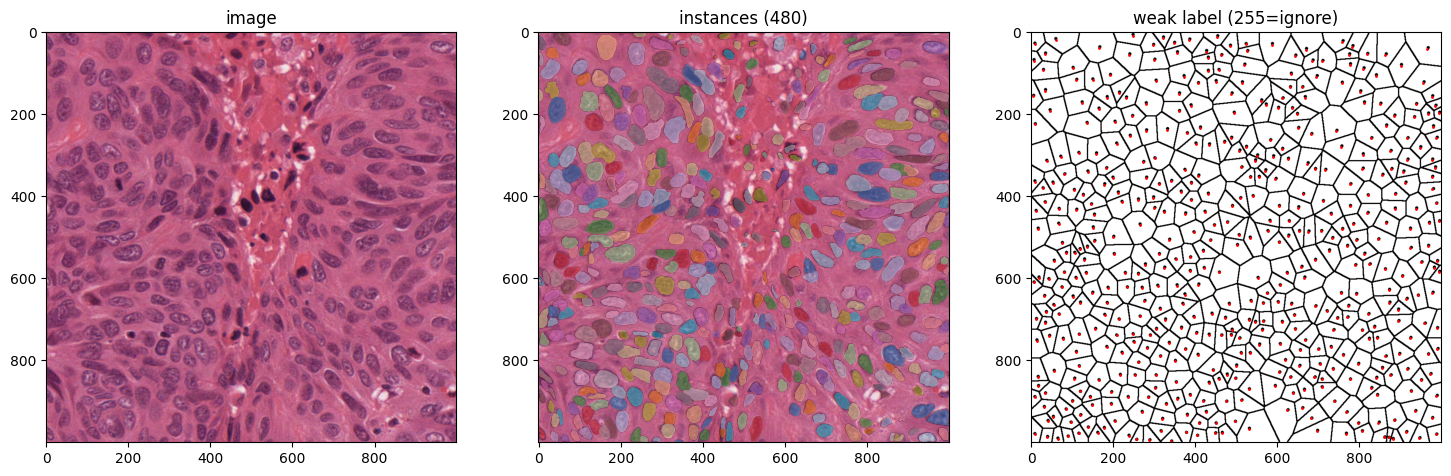

In [ ]:
%%skip_if PREP_DONE
import matplotlib.pyplot as plt
stem = stems_img[0]
img = cv2.cvtColor(cv2.imread(f"{RAW}/images/{stem}.tif"), cv2.COLOR_BGR2RGB)
inst = np.load(f"{OUT}/inst/{stem}.npy")
weak = cv2.imread(f"{OUT}/weak/{stem}.png", 0)
pts = np.load(f"{OUT}/points/{stem}.npy")

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img); ax[0].set_title("image")
ax[1].imshow(img); ax[1].imshow(np.ma.masked_equal(inst, 0) % 20, cmap="tab20", alpha=0.5)
ax[1].set_title(f"instances ({inst.max()})")
ax[2].imshow(weak, cmap="gray"); ax[2].plot(pts[:, 1], pts[:, 0], "r.", ms=2)
ax[2].set_title("weak label (255=ignore)")
plt.show()

Full mask: xml map to instances

Weak label: use center of mass

In [ ]:
%%skip_if PREP_DONE
from collections import defaultdict
groups = defaultdict(list)
for s in stems_img:
    groups[s.split("-")[1]].append(s)   # second field = TSS code
for tss, ss in sorted(groups.items()):
    print(tss, len(ss), [x[5:12] for x in ss])
print("Total", len(groups), "TSS codes")

18 1 ['18-5592']
21 2 ['21-5784', '21-5786']
38 1 ['38-6178']
49 1 ['49-4488']
50 1 ['50-5931']
A7 2 ['A7-A13E', 'A7-A13F']
AR 2 ['AR-A1AK', 'AR-A1AS']
AY 1 ['AY-A8YK']
B0 3 ['B0-5698', 'B0-5710', 'B0-5711']
BC 1 ['BC-A217']
CH 1 ['CH-5767']
DK 1 ['DK-A2I6']
E2 2 ['E2-A14V', 'E2-A1B5']
F9 1 ['F9-A8NY']
FG 1 ['FG-A87N']
G2 1 ['G2-A2EK']
G9 5 ['G9-6336', 'G9-6348', 'G9-6356', 'G9-6362', 'G9-6363']
HE 3 ['HE-7128', 'HE-7129', 'HE-7130']
KB 1 ['KB-A93J']
MH 1 ['MH-A561']
NH 1 ['NH-A8F7']
RD 1 ['RD-A8N9']
UZ 2 ['UZ-A9PJ', 'UZ-A9PN']
XS 1 ['XS-A8TJ']
Total 24 TSS codes


In [ ]:
%%skip_if PREP_DONE
import json, random
from collections import defaultdict

SEED, N_VAL = 0, 6
rng = random.Random(SEED)

groups = defaultdict(list)
for s in stems_img:
    groups[s.split("-")[1]].append(s)

multi = sorted(k for k, v in groups.items() if len(v) >= 2)
chosen_groups = rng.sample(multi, N_VAL)
val = [rng.choice(sorted(groups[k])) for k in chosen_groups]
train = [s for s in stems_img if s not in val]

split = {"seed": SEED, "train": train, "val": val}
json.dump(split, open(f"{OUT}/split.json", "w"), indent=1)

print("train:", len(train), "| val:", len(val))
print("val:", val)
print("val nuclei:", sum(summary[s]["n_nuclei"] for s in val),
      "| train nuclei:", sum(summary[s]["n_nuclei"] for s in train))

train: 31 | val: 6
val: ['TCGA-HE-7129-01Z-00-DX1', 'TCGA-UZ-A9PN-01Z-00-DX1', 'TCGA-B0-5710-01Z-00-DX1', 'TCGA-21-5786-01Z-00-DX1', 'TCGA-AR-A1AS-01Z-00-DX1', 'TCGA-G9-6363-01Z-00-DX1']
val nuclei: 4349 | train nuclei: 19784


In [ ]:
%%skip_if PREP_DONE
# 1000 -> 3 starts (0, 256, 488): the last start is flush with the edge to avoid partial tiles
def starts(L, size=512, stride=256):
    s = list(range(0, L - size + 1, stride))
    if s[-1] != L - size:
        s.append(L - size)
    return s

print(starts(1000))   # [0, 256, 488], 3x3 = 9 tiles per image

[0, 256, 488]


In [ ]:
%%skip_if PREP_DONE
import json, numpy as np

split = json.load(open(f"{OUT}/split.json"))
tiles = {"train": [], "val": []}

for part in ["train", "val"]:
    for stem in split[part]:
        h, w = summary[stem]["h"], summary[stem]["w"]
        for y in starts(h):
            for x in starts(w):
                inst = np.load(f"{OUT}/inst/{stem}.npy", mmap_mode="r")[y:y+512, x:x+512]
                tiles[part].append({"stem": stem, "y": y, "x": x,
                                    "n_gt": int(len(np.unique(inst)) - (0 in inst))})

json.dump(tiles, open(f"{OUT}/tiles.json", "w"))
print({k: len(v) for k, v in tiles.items()})

{'train': 279, 'val': 54}


## 3. SAM ViT-B embedding cache (⏭ auto-skipped when `CACHE_DONE`)

Loads SAM, freezes the encoder, and caches 256×64×64 embeddings for every tile (8 dihedral augs for train, 1 for val) to `cache/emb_vitb/`.

In [ ]:
%%skip_if CACHE_DONE
CKPT = f"{ROOT}/checkpoints/sam_vit_b_01ec64.pth"
if not os.path.exists(CKPT):
    !wget -q -O {CKPT} https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
print("Checkpoint size:", os.path.getsize(CKPT) / 1e6, "MB")

Checkpoint size: 375.042383 MB


In [ ]:
%%skip_if CACHE_DONE
import torch
from segment_anything import sam_model_registry

device = "cuda"
sam = sam_model_registry["vit_b"](checkpoint=CKPT).to(device)
print("Num params:", sum(p.numel() for p in sam.parameters()) / 1e6, "M")

Num params: 93.735472 M


In [ ]:
%%skip_if CACHE_DONE
for p in sam.image_encoder.parameters():
    p.requires_grad = False
for p in sam.prompt_encoder.parameters():
    p.requires_grad = False

trainable = sum(p.numel() for p in sam.parameters() if p.requires_grad)
print("Trainable params:", trainable / 1e6, "M")  # mask decoder is ~4M

Trainable params: 4.05834 M


In [ ]:
%%skip_if CACHE_DONE
x = torch.randn(1, 3, 1024, 1024, device=device)
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    emb = sam.image_encoder(x)
print(emb.shape)

KeyboardInterrupt: 

In [ ]:
%%skip_if CACHE_DONE
import os, json, cv2, numpy as np, torch
import torch.nn.functional as F
from tqdm import tqdm

RAW = "/content/drive/MyDrive/s_seg_rlvr/data/monuseg/raw/train"
CACHE = "/content/drive/MyDrive/s_seg_rlvr/cache/emb_vitb"
os.makedirs(CACHE, exist_ok=True)

tiles = json.load(open(f"{OUT}/tiles.json"))
mean = torch.tensor([123.675, 116.28, 103.53], device="cuda").view(1, 3, 1, 1)
std = torch.tensor([58.395, 57.12, 57.375], device="cuda").view(1, 3, 1, 1)

sam.eval()
img_cache = {}  # reuse the loaded image across its tiles

for part in ["train", "val"]:
    augs = range(8) if part == "train" else [0]
    for t in tqdm(tiles[part], desc=part):
        stem, y, x = t["stem"], t["y"], t["x"]
        if stem not in img_cache:
            img_cache.clear()
            im = cv2.cvtColor(cv2.imread(f"{RAW}/images/{stem}.tif"), cv2.COLOR_BGR2RGB)
            img_cache[stem] = im
        tile = img_cache[stem][y:y+512, x:x+512]

        for k in augs:
            path = f"{CACHE}/{stem}_{y}_{x}_a{k}.npy"
            if os.path.exists(path):      # resume from checkpoint
                continue
            a = apply_aug(tile, k)
            ten = torch.from_numpy(a).permute(2, 0, 1)[None].float().cuda()
            ten = F.interpolate(ten, size=(1024, 1024), mode="bilinear", align_corners=False)
            ten = (ten - mean) / std
            with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
                emb = sam.image_encoder(ten)
            np.save(path, emb.squeeze(0).half().cpu().numpy())

val: 100%|██████████| 54/54 [00:12<00:00,  4.42it/s]


In [ ]:
%%skip_if CACHE_DONE
f = sorted(os.listdir(CACHE))[0]
e = np.load(f"{CACHE}/{f}")
print(f, e.shape, e.dtype, "| has NaN:", np.isnan(e).any(), "| mean/std:", e.mean(), e.std())

TCGA-18-5592-01Z-00-DX1_0_0_a0.npy (256, 64, 64) float16 | has NaN: False | mean/std: 0.014725 0.1522


In [ ]:
%%skip_if CACHE_DONE
import glob
files = sorted(glob.glob(f"{CACHE}/*.npy"))
print("Total files:", len(files), "(expected 2286)")

bad = []
for f in tqdm(files):
    e = np.load(f)
    if not np.isfinite(e).all():
        bad.append(f)
print("Files with NaN/Inf:", len(bad))

Total files: 2286 (expected 2286)


100%|██████████| 2286/2286 [00:15<00:00, 148.33it/s]

Files with NaN/Inf: 0


## 4. Post-processing reference

Sanity check of the metrics (GT → GT) and the ceiling of each post-processing method given a perfect semantic mask.

In [ ]:
# Self-test A: GT as prediction, expect PQ=1, merge=0, split=0, cnt_err=0
rows = [metrics(np.load(f"{PROC}/inst/{s}.npy"), np.load(f"{PROC}/inst/{s}.npy"),
                np.load(f"{PROC}/points/{s}.npy")) for s in val]
summarize(rows, "Self-test A GT->GT")

# Check B (upper-bound reference): merge GT foreground into 0/1, then CC directly.
# This is "the best any pixel-level model can do with CC given perfect semantic segmentation"
rows = []
for s in val:
    gt = np.load(f"{PROC}/inst/{s}.npy")
    rows.append(metrics(gt, post_cc((gt > 0).astype(np.float32)), np.load(f"{PROC}/points/{s}.npy")))
summarize(rows, "Check B perfect semantic mask+CC")

Self-test A GT->GT {'PQ': 1.0, 'DQ': 1.0, 'SQ': 1.0, 'merge_rate': 0.0, 'split_rate': 0.0, 'cnt_err/img': 0.0, 'n_pred/n_gt': 1.0}
Check B perfect semantic mask+CC {'PQ': 0.779, 'DQ': 0.825, 'SQ': 0.942, 'merge_rate': 0.188, 'split_rate': 0.0, 'cnt_err/img': 179.5, 'n_pred/n_gt': 0.752}


{'PQ': np.float64(0.779320837627942),
 'DQ': np.float64(0.824519471702912),
 'SQ': np.float64(0.942245293734466),
 'merge_rate': np.float64(0.18794600575146184),
 'split_rate': np.float64(0.0),
 'cnt_err/img': np.float64(179.5),
 'n_pred/n_gt': 0.7523568636468153}

In [ ]:
rows = []
for s in val:
    gt = np.load(f"{PROC}/inst/{s}.npy")
    rows.append(metrics(gt, post_ws((gt > 0).astype(np.float32)), np.load(f"{PROC}/points/{s}.npy")))
summarize(rows, "Check B' perfect semantic mask+watershed")

Check B' perfect semantic mask+watershed {'PQ': 0.866, 'DQ': 0.916, 'SQ': 0.945, 'merge_rate': 0.016, 'split_rate': 0.103, 'cnt_err/img': 63.833, 'n_pred/n_gt': 1.061}


{'PQ': np.float64(0.8662497325646591),
 'DQ': np.float64(0.9155298214106561),
 'SQ': np.float64(0.9448369877575963),
 'merge_rate': np.float64(0.015864068935689455),
 'split_rate': np.float64(0.10302992453908617),
 'cnt_err/img': np.float64(63.833333333333336),
 'n_pred/n_gt': 1.0613934237755807}

## 5. Baseline 2: full masks (upper bound)

### Train (⏭ auto-skipped once `full_s0.pt` reaches 5000 steps)

In [ ]:
%%skip_if trained("full")
head_full = train("full", "full", steps=5000)

/tmp/ipykernel_4236/653449930.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


100 0.6777
200 0.5169
300 0.5629
400 0.5653
500 0.4694
600 0.4402
700 0.4471
800 0.4252
900 0.4120
1000 0.3739
1100 0.3978
1200 0.4094
1300 0.4221
1400 0.3844
1500 0.4133
1600 0.4489
1700 0.3780
1800 0.4190
1900 0.4441
2000 0.4186
2100 0.4080
2200 0.3833
2300 0.3896
2400 0.4319
2500 0.4430
2600 0.3866
2700 0.3957
2800 0.3528
2900 0.3689
3000 0.3527
3100 0.4434
3200 0.3982
3300 0.3323
3400 0.4545
3500 0.4130
3600 0.3605
3700 0.3994
3800 0.3932
3900 0.3832
4000 0.3723
4100 0.3980
4200 0.4100
4300 0.3567
4400 0.3847
4500 0.3656
4600 0.4225
4700 0.4062
4800 0.3542
4900 0.3690
5000 0.3812


### Evaluate

In [ ]:
head = SegHead().cuda()
head.load_state_dict(torch.load(f"{ROOT}/checkpoints/full_s0.pt")["head"])
probs = stitch_probs(head)
evaluate(probs, post_cc, "full / CC")
evaluate(probs, post_ws, "full / watershed")

infer: 100%|██████████| 54/54 [00:35<00:00,  1.51it/s]


full / CC {'PQ': 0.464, 'DQ': 0.627, 'SQ': 0.738, 'merge_rate': 0.158, 'split_rate': 0.001, 'cnt_err/img': 193.667, 'n_pred/n_gt': 0.76}
full / watershed {'PQ': 0.492, 'DQ': 0.665, 'SQ': 0.739, 'merge_rate': 0.043, 'split_rate': 0.079, 'cnt_err/img': 116.833, 'n_pred/n_gt': 1.044}


{'PQ': np.float64(0.49226438050582216),
 'DQ': np.float64(0.6648904165414543),
 'SQ': np.float64(0.7387045542287392),
 'merge_rate': np.float64(0.043051792711272296),
 'split_rate': np.float64(0.07946330924214134),
 'cnt_err/img': np.float64(116.83333333333333),
 'n_pred/n_gt': 1.0439181421016326}

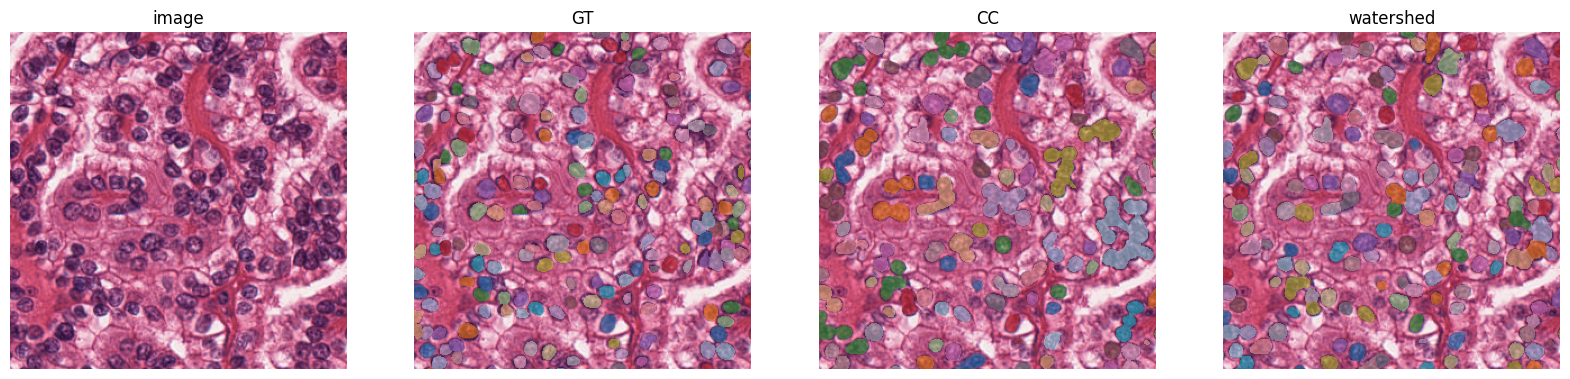

In [ ]:
import matplotlib.pyplot as plt
s = val[0]
img = cv2.cvtColor(cv2.imread(f"{RAW}/images/{s}.tif"), cv2.COLOR_BGR2RGB)
gt = np.load(f"{PROC}/inst/{s}.npy")
pc, pw = post_cc(probs[s]), post_ws(probs[s])
y0, x0, S = 300, 300, 300   # look at a dense region
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a, (t, im) in zip(ax, [("image", None), ("GT", gt), ("CC", pc), ("watershed", pw)]):
    a.imshow(img[y0:y0+S, x0:x0+S])
    if im is not None:
        a.imshow(np.ma.masked_equal(im[y0:y0+S, x0:x0+S], 0) % 20, cmap="tab20", alpha=0.55)
    a.set_title(t); a.axis("off")
plt.show()

(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

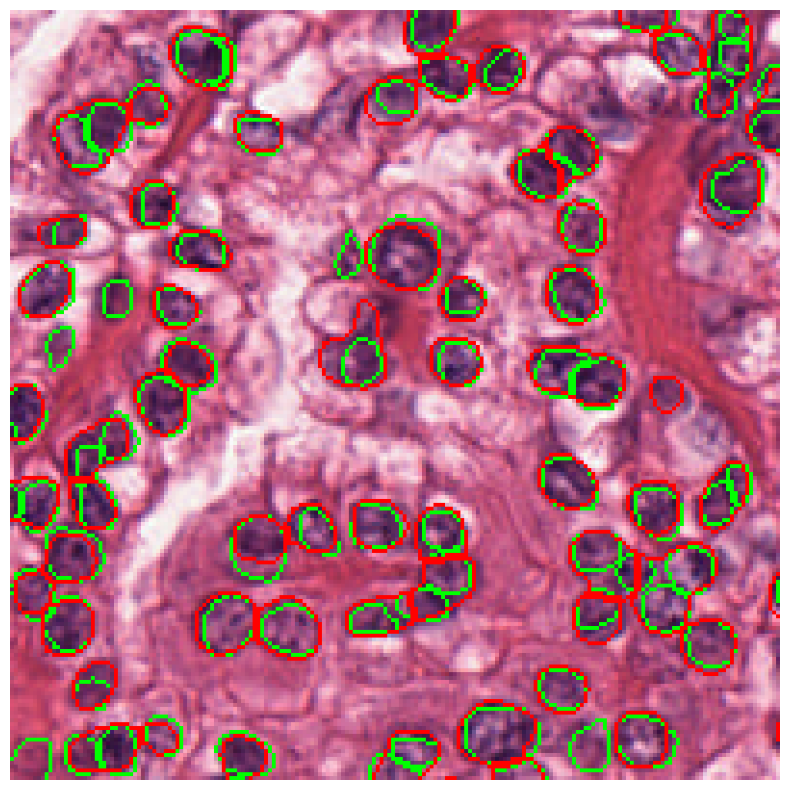

In [ ]:
s = val[0]
img = cv2.cvtColor(cv2.imread(f"{RAW}/images/{s}.tif"), cv2.COLOR_BGR2RGB)
gt = np.load(f"{PROC}/inst/{s}.npy")
plt.figure(figsize=(10, 10)); plt.imshow(overlay(img, gt, post_ws(probs[s]), 300, 300)); plt.axis("off")

In [ ]:
ratios = []
for s in val:
    g = np.load(f"{PROC}/inst/{s}.npy"); p = post_ws(probs[s])
    ag, ap = np.bincount(g.ravel()), np.bincount(p.ravel())
    m = (g > 0) & (p > 0)
    P = p.max() + 1
    u, inter = np.unique(g[m].astype(np.int64) * P + p[m], return_counts=True)
    gi, pi = u // P, u % P
    iou = inter / (ag[gi] + ap[pi] - inter)
    k = iou > 0.5
    ratios += (ap[pi[k]] / ag[gi[k]]).tolist()
print("Pred/GT area ratio median:", np.median(ratios), "| 25%-75%:", np.percentile(ratios, [25, 75]))

Pred/GT area ratio median: 0.9546742209631728 | 25%-75%: [0.81541043 1.1558037 ]


In [ ]:
def recall_table(thr, edges=None):
    areas, hits = [], []
    for s in val:
        a, h = miss_by_size(np.load(f"{PROC}/inst/{s}.npy"), post_ws(probs[s]), thr)
        areas.append(a); hits.append(h)
    areas, hits = np.concatenate(areas), np.concatenate(hits)
    if edges is None:
        edges = np.quantile(areas, [0, .25, .5, .75, 1])
    print(f"--- IoU > {thr} ---")
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (areas >= lo) & (areas <= hi)
        print(f"Area {lo:.0f}-{hi:.0f} px: recall {hits[sel].mean():.2f} (n={sel.sum()})")
    return edges

edges = recall_table(0.5)          # should match the earlier result; serves as a sanity check
recall_table(0.3, edges)

--- IoU > 0.5 ---
Area 3-132 px: recall 0.47 (n=1100)
Area 132-244 px: recall 0.74 (n=1098)
Area 244-425 px: recall 0.86 (n=1098)
Area 425-2169 px: recall 0.73 (n=1090)
--- IoU > 0.3 ---
Area 3-132 px: recall 0.64 (n=1100)
Area 132-244 px: recall 0.88 (n=1098)
Area 244-425 px: recall 0.94 (n=1098)
Area 425-2169 px: recall 0.89 (n=1090)


array([   3.,  132.,  244.,  425., 2169.])

## 6. Baseline 1: weak labels (lower bound)

`pos_weight` = background/foreground pixel ratio of the weak labels (first 60 train tiles), used by the weak-label loss.

In [ ]:
fg = bg = 0
for t in json.load(open(f"{PROC}/tiles.json"))["train"][:60]:
    w = cv2.imread(f"{PROC}/weak/{t['stem']}.png", 0)[t["y"]:t["y"]+512, t["x"]:t["x"]+512]
    fg += (w == 1).sum(); bg += (w == 0).sum()
print("Foreground:", fg, "Background:", bg, "bg/fg:", bg / max(fg, 1))

Foreground: 326580 Background: 2166409 bg/fg: 6.633624226835691


### Train (⏭ auto-skipped once `weak_s0.pt` reaches 5000 steps)

In [ ]:
%%skip_if trained("weak")
head_weak = train("weak", "weak", steps=5000, pos_weight=6.6, seed=0)

/tmp/ipykernel_3760/653449930.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


100 0.7991
200 0.5745
300 0.5214
400 0.5532
500 0.4366
600 0.4254
700 0.4085
800 0.3668
900 0.4538
1000 0.3154
1100 0.3410
1200 0.3067
1300 0.3911
1400 0.3523
1500 0.4031
1600 0.3507
1700 0.3595
1800 0.3751
1900 0.3572
2000 0.4212
2100 0.3147
2200 0.2846
2300 0.3254
2400 0.3189
2500 0.3733
2600 0.3563
2700 0.2732
2800 0.3052
2900 0.3017
3000 0.3051
3100 0.3446
3200 0.2915
3300 0.2730
3400 0.2990
3500 0.2912
3600 0.2300
3700 0.3847
3800 0.2644
3900 0.2651
4000 0.2462
4100 0.3412
4200 0.2596
4300 0.2158
4400 0.2841
4500 0.2430
4600 0.2621
4700 0.3567
4800 0.1917
4900 0.2206
5000 0.2433


### Evaluate and compare with Baseline 2

In [ ]:
head_w = SegHead().cuda()
head_w.load_state_dict(torch.load(f"{ROOT}/checkpoints/weak_s0.pt")["head"])
probs_w = stitch_probs(head_w)
evaluate(probs_w, post_cc, "weak / CC")
evaluate(probs_w, post_ws, "weak / watershed")

infer: 100%|██████████| 54/54 [00:00<00:00, 58.47it/s]


weak / CC {'PQ': 0.299, 'DQ': 0.473, 'SQ': 0.625, 'merge_rate': 0.063, 'split_rate': 0.001, 'cnt_err/img': 112.667, 'n_pred/n_gt': 0.966}
weak / watershed {'PQ': 0.289, 'DQ': 0.458, 'SQ': 0.621, 'merge_rate': 0.021, 'split_rate': 0.048, 'cnt_err/img': 128.167, 'n_pred/n_gt': 1.177}


{'PQ': np.float64(0.28935138106224106),
 'DQ': np.float64(0.4584349909676226),
 'SQ': np.float64(0.6207910647310309),
 'merge_rate': np.float64(0.02069195490200405),
 'split_rate': np.float64(0.048430351940404924),
 'cnt_err/img': np.float64(128.16666666666666),
 'n_pred/n_gt': 1.1768222579903427}

In [ ]:
# 1. Foreground ratio: predicted foreground fraction vs GT foreground fraction
for s in val[:3]:
    gt_fg = (np.load(f"{PROC}/inst/{s}.npy") > 0).mean()
    print(s[:12], "GT fg:", round(float(gt_fg), 3),
          "| fully-sup:", round(float((probs[s] > .5).mean()), 3),
          "| weakly-sup:", round(float((probs_w[s] > .5).mean()), 3))

TCGA-HE-7129 GT fg: 0.197 | fully-sup: 0.236 | weakly-sup: 0.225
TCGA-UZ-A9PN GT fg: 0.328 | fully-sup: 0.263 | weakly-sup: 0.194
TCGA-B0-5710 GT fg: 0.117 | fully-sup: 0.097 | weakly-sup: 0.081


In [ ]:
for name, pd_ in [("fully-sup", probs), ("weakly-sup", probs_w)]:
    for pname, post in [("CC", post_cc), ("watershed", post_ws)]:
        med, iqr, n = area_ratio(pd_, post)
        rec = recall_by_size(pd_, edges, post)
        print(f"{name}/{pname}: area ratio median {med:.2f}, IQR {iqr.round(2)}, matched nuclei {n} | recall by size bin {rec}")

fully-sup/CC: area ratio median 0.93, IQR [0.81 1.15], matched nuclei 2277 | recall by size bin [0.23, 0.45, 0.74, 0.67]
fully-sup/watershed: area ratio median 0.95, IQR [0.82 1.16], matched nuclei 3047 | recall by size bin [0.47, 0.74, 0.86, 0.73]
weakly-sup/CC: area ratio median 0.73, IQR [0.6 1. ], matched nuclei 2213 | recall by size bin [0.37, 0.63, 0.7, 0.34]
weakly-sup/watershed: area ratio median 0.78, IQR [0.62 1.05], matched nuclei 2561 | recall by size bin [0.59, 0.77, 0.72, 0.28]


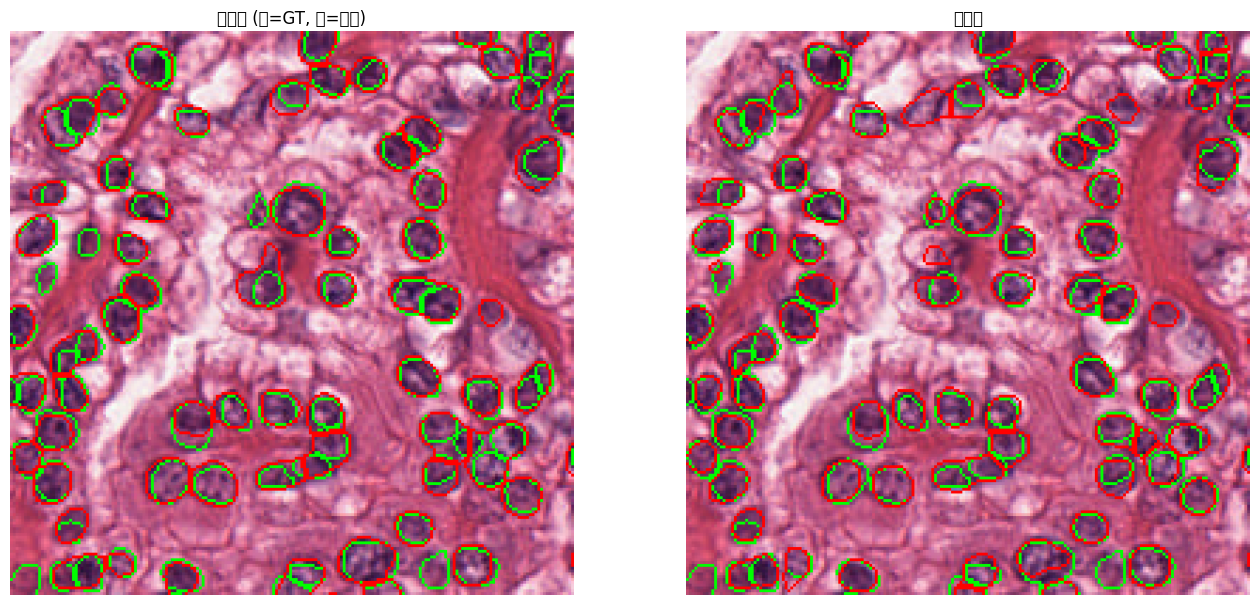

In [ ]:
s = val[0]
img = cv2.cvtColor(cv2.imread(f"{RAW}/images/{s}.tif"), cv2.COLOR_BGR2RGB)
gt = np.load(f"{PROC}/inst/{s}.npy")
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(overlay(img, gt, post_ws(probs[s]), 300, 300)); ax[0].set_title("Fully-sup (green=GT, red=pred)")
ax[1].imshow(overlay(img, gt, post_ws(probs_w[s]), 300, 300)); ax[1].set_title("Weakly-sup")
for a in ax: a.axis("off")
plt.show()

In [ ]:
for pname, post in [("CC", post_cc), ("watershed", post_ws)]:
    r05 = recall_by_size(probs_w, edges, post, thr=0.5)
    r03 = recall_by_size(probs_w, edges, post, thr=0.3)
    print(f"weakly-sup/{pname}  IoU>0.5: {r05}")
    print(f"weakly-sup/{pname}  IoU>0.3: {r03}")

weakly-sup/CC  IoU>0.5: [0.37, 0.63, 0.7, 0.34]
weakly-sup/CC  IoU>0.3: [0.54, 0.8, 0.95, 0.86]
weakly-sup/watershed  IoU>0.5: [0.59, 0.77, 0.72, 0.28]
weakly-sup/watershed  IoU>0.3: [0.79, 0.91, 0.96, 0.75]


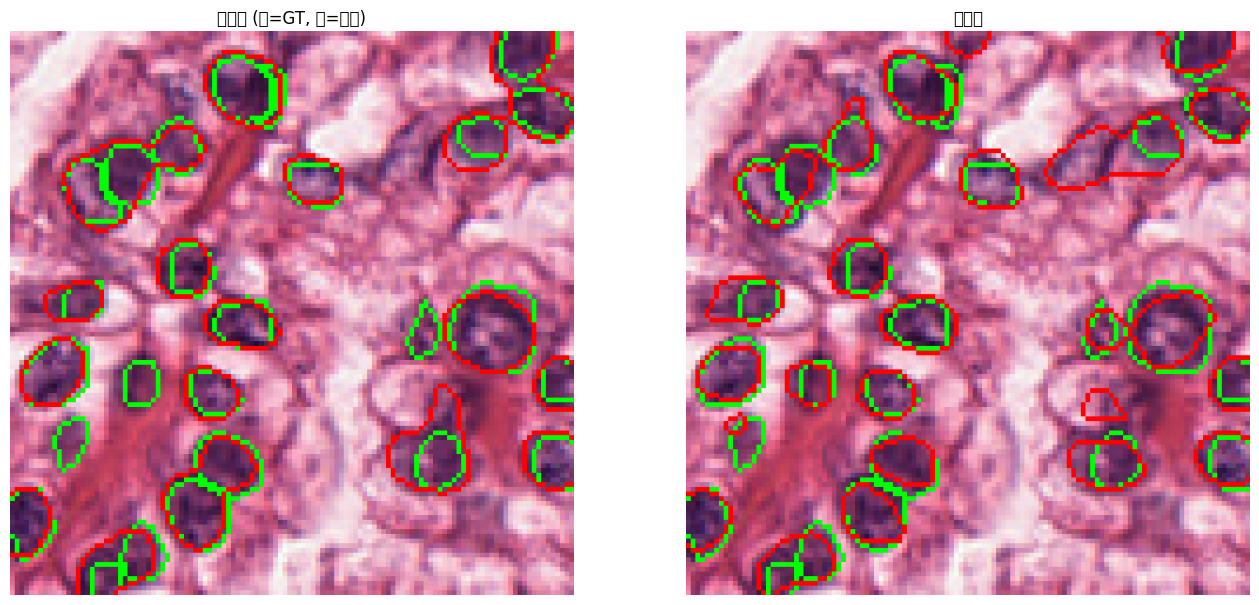

In [ ]:
s = val[0]
img = cv2.cvtColor(cv2.imread(f"{RAW}/images/{s}.tif"), cv2.COLOR_BGR2RGB)
gt = np.load(f"{PROC}/inst/{s}.npy")

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(overlay(img, gt, post_cc(probs[s]), 300, 300, S=120)); ax[0].set_title("Fully-sup (green=GT, red=pred)")
ax[1].imshow(overlay(img, gt, post_cc(probs_w[s]), 300, 300, S=120)); ax[1].set_title("Weakly-sup")
for a in ax: a.axis("off")
plt.show()

In [ ]:
inside, ratio = [], []
for s in val:
    g = np.load(f"{PROC}/inst/{s}.npy"); p = post_cc(probs_w[s])
    ag, ap = np.bincount(g.ravel()), np.bincount(p.ravel())
    m = (g > 0) & (p > 0)
    P = p.max() + 1
    u, inter = np.unique(g[m].astype(np.int64) * P + p[m], return_counts=True)
    gi, pi = u // P, u % P
    sel = inter / ap[pi] > 0.5          # most of the predicted pixels fall inside this GT
    inside += (inter[sel] / ap[pi[sel]]).tolist()
    ratio += (ap[pi[sel]] / ag[gi[sel]]).tolist()
print("Fraction of pred pixels inside matched GT, median:", np.median(inside))
print("Pred/GT area ratio median:", np.median(ratio))

Fraction of pred pixels inside matched GT, median: 0.9812206572769953
Pred/GT area ratio median: 0.6307692307692307


### Weak-label disc radius check (train labels only, no model)

In [ ]:
from scipy import ndimage as ndi
tr = json.load(open(f"{PROC}/split.json"))["train"]
cands = [4, 6, 8, 10]
res = {r: {"inside": [], "ratio": []} for r in cands}
for s in tr:
    inst = np.load(f"{PROC}/inst/{s}.npy")
    pts = np.load(f"{PROC}/points/{s}.npy")
    h, w = inst.shape
    yy, xx = np.ogrid[:h, :w]
    areas = np.bincount(inst.ravel())
    for (cy, cx) in pts:
        iy, ix = int(round(cy)), int(round(cx))
        if not (0 <= iy < h and 0 <= ix < w): continue
        i = inst[iy, ix]
        if i == 0: continue          # centroids falling outside the nucleus are counted separately; skip here
        for r in cands:
            y0, y1, x0, x1 = max(iy-r,0), min(iy+r+1,h), max(ix-r,0), min(ix+r+1,w)
            sub = inst[y0:y1, x0:x1]
            yy_, xx_ = np.ogrid[y0:y1, x0:x1]
            disc = (yy_-iy)**2 + (xx_-ix)**2 <= r*r
            res[r]["inside"].append((sub[disc] == i).mean())
            res[r]["ratio"].append(disc.sum() / areas[i])
for r in cands:
    print(f"r={r}: disc fraction inside own instance, median {np.median(res[r]['inside']):.2f}, "
          f"10th pct {np.percentile(res[r]['inside'],10):.2f}, "
          f"disc/instance area, median {np.median(res[r]['ratio']):.2f}")

r=4: disc fraction inside own instance, median 1.00, 10th pct 1.00, disc/instance area, median 0.15
r=6: disc fraction inside own instance, median 1.00, 10th pct 0.81, disc/instance area, median 0.36
r=8: disc fraction inside own instance, median 0.99, 10th pct 0.54, disc/instance area, median 0.62
r=10: disc fraction inside own instance, median 0.85, 10th pct 0.35, disc/instance area, median 1.00


# Baseline Results (MoNuSeg val, 6 images, seed 0)

## 1. Instance segmentation metrics

| Condition | Post-proc | PQ | DQ | SQ | n_pred / n_gt | Merge rate | Split rate | Count err / img |
|---|---|---|---|---|---|---|---|---|
| Perfect semantic (GT, reference) | CC | 0.779 | 0.825 | 0.942 | 0.75 | 0.188 | 0.000 | 179.5 |
| Perfect semantic (GT, reference) | Watershed | 0.866 | 0.916 | 0.945 | 1.06 | 0.016 | 0.103 | 63.8 |
| **Baseline 2 (full masks)** | CC | 0.464 | 0.627 | 0.738 | 0.76 | 0.158 | 0.001 | 193.7 |
| **Baseline 2 (full masks)** | Watershed | 0.492 | 0.665 | 0.739 | 1.04 | 0.043 | 0.079 | 116.8 |
| **Baseline 1 (weak labels)** | CC | 0.299 | 0.473 | 0.625 | 0.97 | 0.063 | 0.001 | 112.7 |
| **Baseline 1 (weak labels)** | Watershed | 0.289 | 0.458 | 0.621 | 1.18 | 0.021 | 0.048 | 128.2 |

## 2. Predicted / GT area ratio (matched pairs, IoU > 0.5)

| Condition | Post-proc | Median | IQR (25%-75%) | Matched nuclei |
|---|---|---|---|---|
| Baseline 2 (full masks) | CC | 0.93 | 0.81 - 1.15 | 2277 |
| Baseline 2 (full masks) | Watershed | 0.95 | 0.82 - 1.16 | 3047 |
| Baseline 1 (weak labels) | CC | 0.73 | 0.60 - 1.00 | 2213 |
| Baseline 1 (weak labels) | Watershed | 0.78 | 0.62 - 1.05 | 2561 |

## 3. Recall by GT nucleus area (IoU > 0.5)

Area bins (px): 3-132, 132-244, 244-425, 425-2169 (about 1100 nuclei per bin).

| Condition | Post-proc | Smallest | Small-mid | Large-mid | Largest |
|---|---|---|---|---|---|
| Baseline 2 (full masks) | CC | 0.23 | 0.45 | 0.74 | 0.67 |
| Baseline 2 (full masks) | Watershed | 0.47 | 0.74 | 0.86 | 0.73 |
| Baseline 1 (weak labels) | CC | 0.37 | 0.63 | 0.70 | 0.34 |
| Baseline 1 (weak labels) | Watershed | 0.59 | 0.77 | 0.72 | 0.28 |

## 4. Baseline 1 (weak labels): recall at looser matching (diagnostic only)

| Post-proc | IoU threshold | Smallest | Small-mid | Large-mid | Largest |
|---|---|---|---|---|---|
| CC | > 0.5 | 0.37 | 0.63 | 0.70 | 0.34 |
| CC | > 0.3 | 0.54 | 0.80 | 0.95 | 0.86 |
| Watershed | > 0.5 | 0.59 | 0.77 | 0.72 | 0.28 |
| Watershed | > 0.3 | 0.79 | 0.91 | 0.96 | 0.75 |

## Notes

- Single seed (0) and only 6 validation images: treat differences of about 0.02-0.03 as noise.
- Settings fixed across methods: threshold 0.5, min_area 15 px, watershed min_distance 5 px.
- Weak labels: radius-4 px discs + Voronoi boundaries; `pos_weight` = 6.63.
- Baseline 2 uses the 5000-step head; the 15000-step check is not yet run.
- Merge rate = fraction of predicted instances covering >= 2 GT centroids. Split rate = fraction of GT nuclei covered >= 20% by >= 2 predicted instances.
- Per-image PQ averaged over images (not dataset-level accumulation).
- IoU > 0.3 numbers are non-unique matches: diagnostic only, not for reporting as PQ-type metrics.
- Perfect semantic rows use the GT merged mask as input (no model); they are an upper bound for the post-processing, not a baseline.